# Sentiment Analysis: Classic NLP vs Large Language Models
### Dataset: Rotten Tomatoes Movie Reviews (Chapter 4 Source)

Same structure as the Twitter notebook, but using the `rotten_tomatoes` dataset from HuggingFace -- the exact dataset used in Chapter 4 of Hands-On Large Language Models.

The goal is the same: one dataset, multiple models, one fair comparison at the end.

**Structure:**
1. Setup
2. Load Data (rotten_tomatoes via HuggingFace datasets)
3. Exploratory Data Analysis (EDA)
4. Machine Learning: Naive Bayes from scratch
5. LLM: RoBERTa (Twitter, zero-shot inference), Sentence Embeddings + Logistic Regression, Flan-T5
6. Final Comparison

---
## Part 1: Setup

In [1]:
# Uncomment to install if running on Colab or a fresh environment
# !pip install torch transformers sentence-transformers nltk scikit-learn datasets tqdm pandas matplotlib

import re
import string
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

import torch
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import TweetTokenizer

from datasets import load_dataset
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

warnings.filterwarnings('ignore')

nltk.download('stopwords')

# Auto-detect best available device: MPS (Apple Silicon) > CUDA > CPU
if torch.backends.mps.is_available():
    DEVICE = 'mps'
elif torch.cuda.is_available():
    DEVICE = 'cuda:0'
else:
    DEVICE = 'cpu'

print('Setup complete.')
print(f'Using device : {DEVICE}')
print(f'PyTorch      : {torch.__version__}')

Setup complete.
Using device : mps
PyTorch      : 2.12.0


[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/cation/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


---
## Part 2: Load Data

The `rotten_tomatoes` dataset is the one used in Chapter 4 of Hands-On Large Language Models. It contains short movie review snippets labeled as positive (1) or negative (0). The test split has 1,066 samples, which is what Chapter 4 evaluates on.

> **Note:** HuggingFace datasets 4.x requires the full `namespace/name` format. The correct path is `Cornell-Movie-Review-Data/rotten_tomatoes`.

In [2]:
# Load the dataset -- same as Chapter 4
# Full namespace/name required in datasets 4.x
data = load_dataset('Cornell-Movie-Review-Data/rotten_tomatoes')
print(data)

README.md:   0%|          | 0.00/7.46k [00:00<?, ?B/s]

train.parquet:   0%|          | 0.00/699k [00:00<?, ?B/s]

validation.parquet:   0%|          | 0.00/90.0k [00:00<?, ?B/s]

test.parquet:   0%|          | 0.00/92.2k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/8530 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1066 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1066 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 8530
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 1066
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 1066
    })
})


In [3]:
# Extract splits into plain lists
train_x = data['train']['text']
train_y = np.array(data['train']['label'])

test_x  = data['test']['text']
test_y  = np.array(data['test']['label'])

print(f'Training set : {len(train_x)} reviews')
print(f'Test set     : {len(test_x)} reviews')
print(f'Labels       : 0 = Negative, 1 = Positive')

Training set : 8530 reviews
Test set     : 1066 reviews
Labels       : 0 = Negative, 1 = Positive


In [4]:
# Peek at a few samples
for i in range(3):
    label = 'Positive' if train_y[i] == 1 else 'Negative'
    print(f'[{label}] {train_x[i]}')
    print()

[Positive] the rock is destined to be the 21st century's new " conan " and that he's going to make a splash even greater than arnold schwarzenegger , jean-claud van damme or steven segal .

[Positive] the gorgeously elaborate continuation of " the lord of the rings " trilogy is so huge that a column of words cannot adequately describe co-writer/director peter jackson's expanded vision of j . r . r . tolkien's middle-earth .

[Positive] effective but too-tepid biopic



---
## Part 3: Exploratory Data Analysis (EDA)

Movie reviews are quite different from tweets. They tend to be longer sentences written in proper English, without hashtags or emojis. This matters for how well each model will perform.

In [5]:
train_df = pd.DataFrame({'text': train_x, 'label': train_y})
train_df['word_count'] = train_df['text'].apply(lambda t: len(t.split()))
train_df['char_count'] = train_df['text'].apply(len)

print('Label distribution:')
print(train_df['label'].value_counts().rename({0: 'Negative', 1: 'Positive'}))
print()
print('Word count stats:')
print(train_df['word_count'].describe().round(1))

Label distribution:
label
Positive    4265
Negative    4265
Name: count, dtype: int64

Word count stats:
count    8530.0
mean       21.0
std         9.4
min         1.0
25%        14.0
50%        20.0
75%        27.0
max        59.0
Name: word_count, dtype: float64


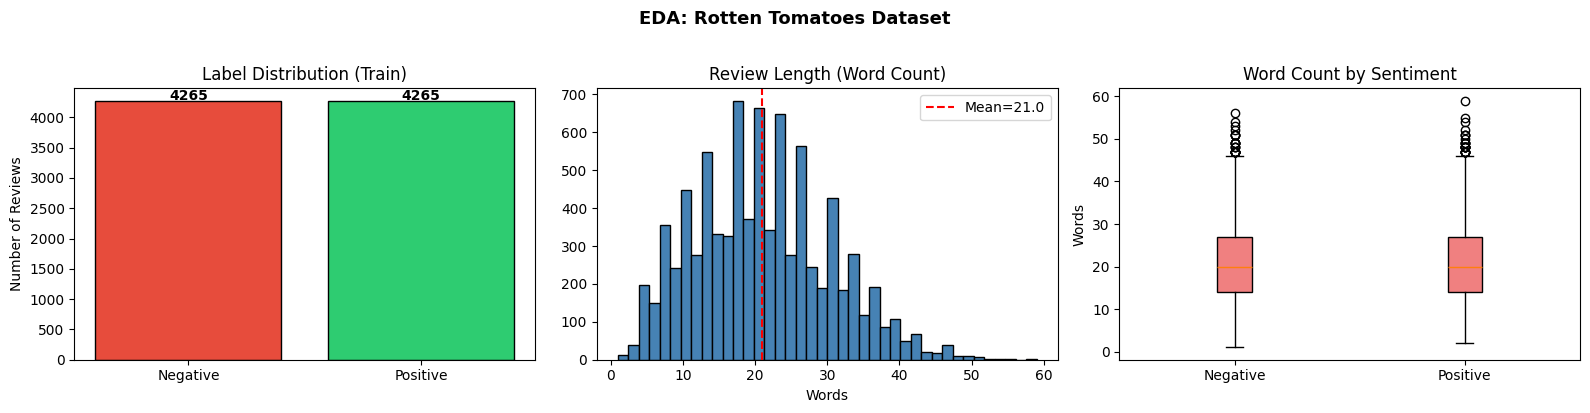

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Plot 1: Class balance
counts = train_df['label'].value_counts().sort_index()
axes[0].bar(['Negative', 'Positive'], counts.values,
            color=['#e74c3c', '#2ecc71'], edgecolor='black')
axes[0].set_title('Label Distribution (Train)')
axes[0].set_ylabel('Number of Reviews')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 20, str(v), ha='center', fontweight='bold')

# Plot 2: Word count histogram
axes[1].hist(train_df['word_count'], bins=40, color='steelblue', edgecolor='black')
axes[1].axvline(train_df['word_count'].mean(), color='red',
                linestyle='--', label=f"Mean={train_df['word_count'].mean():.1f}")
axes[1].set_title('Review Length (Word Count)')
axes[1].set_xlabel('Words')
axes[1].legend()

# Plot 3: Word count by class
neg_wc = train_df[train_df['label'] == 0]['word_count']
pos_wc = train_df[train_df['label'] == 1]['word_count']
axes[2].boxplot([neg_wc, pos_wc], labels=['Negative', 'Positive'],
                patch_artist=True, boxprops=dict(facecolor='lightcoral'))
axes[2].set_title('Word Count by Sentiment')
axes[2].set_ylabel('Words')

plt.suptitle('EDA: Rotten Tomatoes Dataset', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [7]:
# Top words per class
stop = set(stopwords.words('english')) | set(string.punctuation)

def top_words(texts, labels, target_label, n=15):
    words = []
    for t, l in zip(texts, labels):
        if l != target_label:
            continue
        for w in t.lower().split():
            w = re.sub(r'[^a-z]', '', w)
            if w and w not in stop and len(w) > 2:
                words.append(w)
    return Counter(words).most_common(n)

print('Top words in POSITIVE reviews:')
for word, cnt in top_words(train_x, train_y, 1):
    print(f'  {word}: {cnt}')

print()
print('Top words in NEGATIVE reviews:')
for word, cnt in top_words(train_x, train_y, 0):
    print(f'  {word}: {cnt}')

Top words in POSITIVE reviews:
  film: 634
  movie: 412
  one: 277
  like: 214
  story: 190
  comedy: 160
  good: 152
  films: 149
  even: 144
  funny: 140
  way: 135
  characters: 130
  best: 127
  time: 126
  make: 124

Top words in NEGATIVE reviews:
  movie: 617
  film: 509
  like: 359
  one: 287
  story: 180
  much: 177
  bad: 173
  even: 161
  time: 146
  good: 144
  characters: 140
  little: 138
  never: 122
  comedy: 122
  would: 120


### Text preprocessing

Movie reviews do not have Twitter-specific noise like handles or hashtags, but they still benefit from stopword removal and stemming. We adapt the same `process_tweet` logic from Course 01, removing the Twitter-specific regex steps.

In [8]:
def process_text(text):
    """Clean and tokenize a movie review.
    
    Adapted from process_tweet (NLP Specialization Course 01 utils01.py).
    Removes punctuation, lowercases, strips stopwords, applies PorterStemmer.
    Returns a list of stemmed tokens.
    """
    stemmer = PorterStemmer()
    stopwords_english = stopwords.words('english')

    text = re.sub(r'https?://[^\s]+', '', text)  # remove URLs if any
    text = text.lower()

    tokens = re.findall(r"[a-z']+", text)

    cleaned = []
    for word in tokens:
        if word not in stopwords_english and len(word) > 1:
            cleaned.append(stemmer.stem(word))

    return cleaned


# Quick demo
sample_review = "A visually stunning, emotionally resonant film that will stay with you long after the credits roll."
print('Raw  :', sample_review)
print('Clean:', process_text(sample_review))

Raw  : A visually stunning, emotionally resonant film that will stay with you long after the credits roll.
Clean: ['visual', 'stun', 'emot', 'reson', 'film', 'stay', 'long', 'credit', 'roll']


---
## Part 4: Machine Learning -- Naive Bayes from Scratch

Same algorithm as the Twitter notebook. The core logic mirrors Course 01 Assignment 2 exactly.

    score = logprior + sum of loglikelihood(word) for each word

If score > 0, the review is positive.

In [9]:
def count_texts(result, texts, ys):
    """Build a frequency dictionary mapping (word, label) to count.
    
    Same logic as count_tweets from Course 01 Assignment 2,
    adapted for general text (not just tweets).
    """
    for y, text in zip(ys, texts):
        for word in process_text(text):
            pair = (word, y)
            result[pair] = result.get(pair, 0) + 1
    return result


freqs = count_texts({}, train_x, train_y)

print(f'Unique (word, label) pairs: {len(freqs)}')

# Show a few signal words
signal_words = ['brilliant', 'waste', 'love', 'bore', 'masterpiece']
print()
for w in signal_words:
    stem = PorterStemmer().stem(w)
    pos = freqs.get((stem, 1), 0)
    neg = freqs.get((stem, 0), 0)
    print(f'  "{w}" (stem: "{stem}") -> pos: {pos}, neg: {neg}')

Unique (word, label) pairs: 17209

  "brilliant" (stem: "brilliant") -> pos: 24, neg: 6
  "waste" (stem: "wast") -> pos: 4, neg: 33
  "love" (stem: "love") -> pos: 160, neg: 79
  "bore" (stem: "bore") -> pos: 5, neg: 68
  "masterpiece" (stem: "masterpiec") -> pos: 18, neg: 3


In [10]:
def train_naive_bayes(freqs, train_y):
    """Train a Naive Bayes classifier.
    
    Returns logprior and a loglikelihood dictionary.
    Mirrors Course 01 Assignment 2 train_naive_bayes function.
    """
    loglikelihood = {}

    vocab = set(word for (word, label) in freqs)
    V = len(vocab)

    N_pos = N_neg = 0
    for (word, label), count in freqs.items():
        if label > 0:
            N_pos += count
        else:
            N_neg += count

    D_pos = int(np.sum(train_y == 1))
    D_neg = int(np.sum(train_y == 0))

    logprior = np.log(D_pos) - np.log(D_neg)

    for word in vocab:
        freq_pos = freqs.get((word, 1), 0)
        freq_neg = freqs.get((word, 0), 0)

        p_w_pos = (freq_pos + 1) / (N_pos + V)
        p_w_neg = (freq_neg + 1) / (N_neg + V)

        loglikelihood[word] = np.log(p_w_pos / p_w_neg)

    return logprior, loglikelihood


logprior, loglikelihood = train_naive_bayes(freqs, train_y)

print(f'logprior        : {logprior:.4f}')   # close to 0 if balanced
print(f'Vocabulary size : {len(loglikelihood)}')

logprior        : 0.0000
Vocabulary size : 12269


In [11]:
def naive_bayes_predict(text, logprior, loglikelihood):
    """Predict sentiment of a single review.
    
    Returns a float score. Positive score means positive sentiment.
    """
    words = process_text(text)
    score = logprior
    for word in words:
        score += loglikelihood.get(word, 0)
    return score


# Sanity check
samples = [
    'A brilliant and touching masterpiece.',
    'A complete waste of time and money.',
    'The film has its moments but ultimately disappoints.'
]
for s in samples:
    score = naive_bayes_predict(s, logprior, loglikelihood)
    label = 'Positive' if score > 0 else 'Negative'
    print(f'  [{label}] score={score:.3f}  "{s}"')

  [Positive] score=4.194  "A brilliant and touching masterpiece."
  [Negative] score=-3.857  "A complete waste of time and money."
  [Negative] score=-0.490  "The film has its moments but ultimately disappoints."


In [12]:
nb_preds = [1 if naive_bayes_predict(t, logprior, loglikelihood) > 0 else 0
            for t in test_x]

nb_accuracy = accuracy_score(test_y, nb_preds)

print('=== Naive Bayes Results ===')
print(classification_report(
    test_y, nb_preds,
    target_names=['Negative', 'Positive']
))

=== Naive Bayes Results ===
              precision    recall  f1-score   support

    Negative       0.78      0.78      0.78       533
    Positive       0.78      0.78      0.78       533

    accuracy                           0.78      1066
   macro avg       0.78      0.78      0.78      1066
weighted avg       0.78      0.78      0.78      1066



---
## Part 5: Large Language Models

Same three LLM approaches as before, now applied to movie reviews.
It is worth watching how the results shift compared to the Twitter dataset -- movie language is more subtle and nuanced than tweet language.

All models use the device detected in Part 1.

### 5.1 RoBERTa (Twitter, zero-shot inference)

This is the exact model from Chapter 4. It was trained on Twitter data, so applying it to movie reviews is a cross-domain test. Interesting to see whether Twitter-trained sentiment generalizes to film criticism.

In [13]:
from transformers import pipeline
from tqdm import tqdm

model_path = 'cardiffnlp/twitter-roberta-base-sentiment-latest'

roberta_pipe = pipeline(
    'text-classification',
    model=model_path,
    tokenizer=model_path,
    return_all_scores=True,
    device=DEVICE
)

print(f'RoBERTa loaded on {DEVICE}.')

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.weight | UNEXPECTED |  | 
roberta.pooler.dense.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


RoBERTa loaded on mps.


In [14]:
roberta_preds = []

for review in tqdm(test_x, desc='RoBERTa inference'):
    try:
        output = roberta_pipe(review[:512])
        scores = {r['label']: r['score'] for r in output[0]}
        pos_score = scores.get('positive', scores.get('Positive', 0))
        neg_score = scores.get('negative', scores.get('Negative', 0))
        roberta_preds.append(1 if pos_score > neg_score else 0)
    except Exception:
        roberta_preds.append(0)

roberta_accuracy = accuracy_score(test_y, roberta_preds)

print('=== RoBERTa (Twitter, zero-shot inference) Results ===')
print(classification_report(
    test_y, roberta_preds,
    target_names=['Negative', 'Positive']
))

RoBERTa inference: 100%|██████████| 1066/1066 [00:12<00:00, 82.32it/s]

=== RoBERTa (Twitter, zero-shot inference) Results ===
              precision    recall  f1-score   support

    Negative       0.50      1.00      0.67       533
    Positive       0.00      0.00      0.00       533

    accuracy                           0.50      1066
   macro avg       0.25      0.50      0.33      1066
weighted avg       0.25      0.50      0.33      1066



### 5.2 Sentence Embeddings + Logistic Regression

The same model from Chapter 4 -- `all-mpnet-base-v2`. This time it encodes movie reviews instead of tweets. The embeddings capture richer semantic relationships, which may give it an edge over Naive Bayes on longer, more nuanced text.

In [15]:
from sentence_transformers import SentenceTransformer

embed_model = SentenceTransformer('sentence-transformers/all-mpnet-base-v2', device=DEVICE)

print(f'Encoding training reviews on {DEVICE}...')
train_embeddings = embed_model.encode(train_x, show_progress_bar=True)

print('Encoding test reviews...')
test_embeddings  = embed_model.encode(test_x,  show_progress_bar=True)

print(f'Embedding shape: {train_embeddings.shape}')

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Encoding training reviews on mps...


Batches:   0%|          | 0/267 [00:00<?, ?it/s]

Encoding test reviews...


Batches:   0%|          | 0/34 [00:00<?, ?it/s]

Embedding shape: (8530, 768)


In [16]:
lr_clf = LogisticRegression(random_state=42, max_iter=1000)
lr_clf.fit(train_embeddings, train_y)

lr_preds = lr_clf.predict(test_embeddings)
lr_accuracy = accuracy_score(test_y, lr_preds)

print('=== Sentence Embeddings + Logistic Regression Results ===')
print(classification_report(
    test_y, lr_preds,
    target_names=['Negative', 'Positive']
))

=== Sentence Embeddings + Logistic Regression Results ===
              precision    recall  f1-score   support

    Negative       0.85      0.86      0.85       533
    Positive       0.86      0.85      0.85       533

    accuracy                           0.85      1066
   macro avg       0.85      0.85      0.85      1066
weighted avg       0.85      0.85      0.85      1066



### 5.3 Generative LLM: Flan-T5

Same zero-shot approach: give the model a prompt and let it generate an answer. No training on our data at all.

In [17]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

t5_model_name = 'google/flan-t5-small'
t5_tokenizer  = AutoTokenizer.from_pretrained(t5_model_name)
t5_model      = AutoModelForSeq2SeqLM.from_pretrained(t5_model_name).to(DEVICE)
t5_model.eval()

def t5_predict(text, max_new_tokens=5):
    """Run Flan-T5 inference on a single prompt."""
    inputs = t5_tokenizer(text, return_tensors='pt',
                          truncation=True, max_length=512).to(DEVICE)
    with torch.no_grad():
        outputs = t5_model.generate(**inputs, max_new_tokens=max_new_tokens)
    return t5_tokenizer.decode(outputs[0], skip_special_tokens=True)


# Quick test
sample = 'Is the following movie review positive or negative? A breathtaking cinematic experience.'
print('Flan-T5 answer:', t5_predict(sample))

Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


Flan-T5 answer: positive


In [18]:
prompt_prefix = 'Is the following movie review positive or negative? '

t5_preds = []
for review in tqdm(test_x, desc='Flan-T5 inference'):
    prompt = prompt_prefix + review[:400]
    answer = t5_predict(prompt)
    t5_preds.append(0 if answer.strip().lower() == 'negative' else 1)

t5_accuracy = accuracy_score(test_y, t5_preds)

print('=== Flan-T5 (Generative) Results ===')
print(classification_report(
    test_y, t5_preds,
    target_names=['Negative', 'Positive']
))

Flan-T5 inference: 100%|██████████| 1066/1066 [00:43<00:00, 24.58it/s]

=== Flan-T5 (Generative) Results ===
              precision    recall  f1-score   support

    Negative       0.83      0.86      0.85       533
    Positive       0.86      0.83      0.84       533

    accuracy                           0.85      1066
   macro avg       0.85      0.85      0.85      1066
weighted avg       0.85      0.85      0.85      1066



---
## Part 6: Final Comparison

All four models evaluated on the same 1,066 Rotten Tomatoes test reviews.

In [19]:
results = {
    'Naive Bayes (from scratch)':           nb_accuracy,
    'Sentence Embeddings + Logistic Reg':   lr_accuracy,
    'RoBERTa (Twitter, zero-shot inference)':  roberta_accuracy,
    'Flan-T5 (Generative, zero-shot)':     t5_accuracy,
}

print(f'{"Method":<44} {"Accuracy":>9}')
print('-' * 55)
for method, acc in sorted(results.items(), key=lambda x: x[1], reverse=True):
    print(f'{method:<44} {acc:>9.4f}')

Method                                        Accuracy
-------------------------------------------------------
Sentence Embeddings + Logistic Reg              0.8518
Flan-T5 (Generative, zero-shot)                 0.8452
Naive Bayes (from scratch)                      0.7805
RoBERTa (Twitter, zero-shot inference)             0.5000


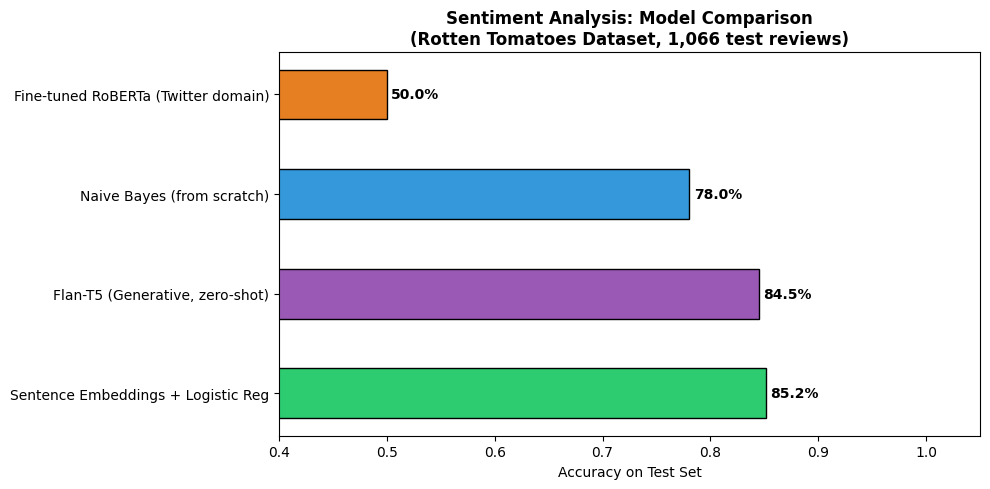

In [20]:
methods    = list(results.keys())
accuracies = list(results.values())
colors     = ['#3498db', '#2ecc71', '#e67e22', '#9b59b6']

sorted_pairs = sorted(zip(accuracies, methods, colors), reverse=True)
accuracies_s, methods_s, colors_s = zip(*sorted_pairs)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(methods_s, accuracies_s,
               color=colors_s, edgecolor='black', height=0.5)

ax.set_xlabel('Accuracy on Test Set')
ax.set_title('Sentiment Analysis: Model Comparison\n(Rotten Tomatoes Dataset, 1,066 test reviews)',
             fontsize=12, fontweight='bold')
ax.set_xlim(0.4, 1.05)

for bar, acc in zip(bars, accuracies_s):
    ax.text(acc + 0.004, bar.get_y() + bar.get_height() / 2,
            f'{acc:.1%}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

## Conclusion

Comparing these results to the Twitter notebook tells an interesting story.

Movie reviews are harder. The language is more formal, more nuanced, and does not rely on the strong signals that make tweets easy to classify. Words like 'interesting', 'ambitious', or 'watchable' can appear in both positive and negative reviews depending on context. Naive Bayes struggles more here because it cannot capture that context.

The sentence embedding approach tends to pull ahead on this dataset. A 768-dimensional dense vector captures meaning at the sentence level, not just at the word level. 'The film tries hard but falls short' and 'The film succeeds where others fail' would look similar to Naive Bayes but land in very different regions of the embedding space.

RoBERTa was trained on Twitter, not on film reviews. That is worth keeping in mind when interpreting its score. It still performs well because general sentiment -- positive vs. negative tone -- transfers across domains. But a model fine-tuned specifically on movie reviews would likely score higher.

Flan-T5 is again doing zero-shot generation. Its performance on movie reviews may be different from tweets because the prompt 'Is the following movie review positive or negative?' is a clear, familiar task that the model has seen during pretraining.

The key takeaway when comparing the two notebooks: the complexity of the text matters a lot. Simple word-level signals dominate in tweets. Richer semantic understanding starts to matter for longer, more formal text.